In [1]:
import xarray as xr
import matplotlib.pyplot as plt
import numpy as np
from scipy.io import loadmat
import pylab as pl
import cmocean
from matplotlib.gridspec import GridSpec
from mpl_toolkits.axes_grid1 import make_axes_locatable
from scipy.interpolate import RegularGridInterpolator

In [2]:
corrinds=[29.96,30.34,30.69,31.03,31.36,31.69,32.05,32.39,32.77,33.15,33.44]

In [3]:
coast='../datafiles/smooth'

dsw = xr.open_dataset(str(coast)+'/Base.nc')

dsn = xr.open_dataset(str(coast)+'/BaseNo.nc')

coast='../datafiles/realistic'

dswO = xr.open_dataset(str(coast)+'/Base.nc')

dsnO = xr.open_dataset(str(coast)+'/BaseNo.nc')


/var/folders/fl/w6vkfnfn7c17jtg6gqg_hb0w0000gn/T/ipykernel_52710/2832909100.py:3: FutureWarning: In a future version of xarray decode_timedelta will default to False rather than None. To silence this warning, set decode_timedelta to True, False, or a 'CFTimedeltaCoder' instance.
  dsw = xr.open_dataset(str(coast)+'/Base/Base.nc')
/var/folders/fl/w6vkfnfn7c17jtg6gqg_hb0w0000gn/T/ipykernel_52710/2832909100.py:5: FutureWarning: In a future version of xarray decode_timedelta will default to False rather than None. To silence this warning, set decode_timedelta to True, False, or a 'CFTimedeltaCoder' instance.
  dsn = xr.open_dataset(str(coast)+'/BaseNO/BaseNo.nc')
/var/folders/fl/w6vkfnfn7c17jtg6gqg_hb0w0000gn/T/ipykernel_52710/2832909100.py:9: FutureWarning: In a future version of xarray decode_timedelta will default to False rather than None. To silence this warning, set decode_timedelta to True, False, or a 'CFTimedeltaCoder' instance.
  dswO = xr.open_dataset(str(coast)+'/Base/Base.nc')

In [4]:
LAT = dsw.YC
LON = dsw.XC - 360
depth = dsw.Depth


hFacC = dsw.hFacC

hfa = np.ma.masked_values(hFacC, 0)
mask = np.ma.getmask(hfa)

#NO BAY

LATn = dsn.YC[1:-1]
LONn = dsn.XC[1:-1] - 360
depthn = dsn.Depth[1:-1,1:-1]


hFacCn = dsn.hFacC[:,1:-1,1:-1].values

hfan = np.ma.masked_values(hFacCn, 0)
maskn = np.ma.getmask(hfan)



In [5]:
LATO = dswO.YC
LONO = dswO.XC - 360
depthorg = dswO.Depth

In [6]:
interp = RegularGridInterpolator((LAT.values,LON.values), depth.values)
interpO = RegularGridInterpolator((LATO.values,LONO.values), depthorg.values)

In [7]:
matfile=loadmat('../datafiles/PALL.mat')
x,dep,lonPl,latPl,deg=matfile['dist'][0][:11],matfile['d'][0][:11],matfile['lon'][0][:11],matfile['lat'][0][:11],matfile['degree'][0][:11]


In [8]:
dep=[]
depOrg=[]
for i in np.arange(0,len(lonPl),1):
    deppre=interp((latPl[i][0],lonPl[i][0]))
    dep.append(deppre)

    deppreOrg=interpO((latPl[i][0],lonPl[i][0]))
    depOrg.append(deppreOrg)



In [9]:
ind_lon = [-115.11813068276555, -115.939167, -116.605833, -117.1625, -118.24368, -119.714167, -120.471439,
           -120.7586085906775]
ind_lat = [27.850440699318973, 30.556389, 31.857778, 32.715, 34.05223, 34.425833, 34.448113, 35.17364705813524]

In [12]:
params = {'font.size': 10,
          'figure.figsize': (7.6, 5),
         'font.family':'sans'}
pl.rcParams.update(params)
plt.rcParams['figure.dpi'] = 1000
plt.rcParams['savefig.dpi'] = 1000

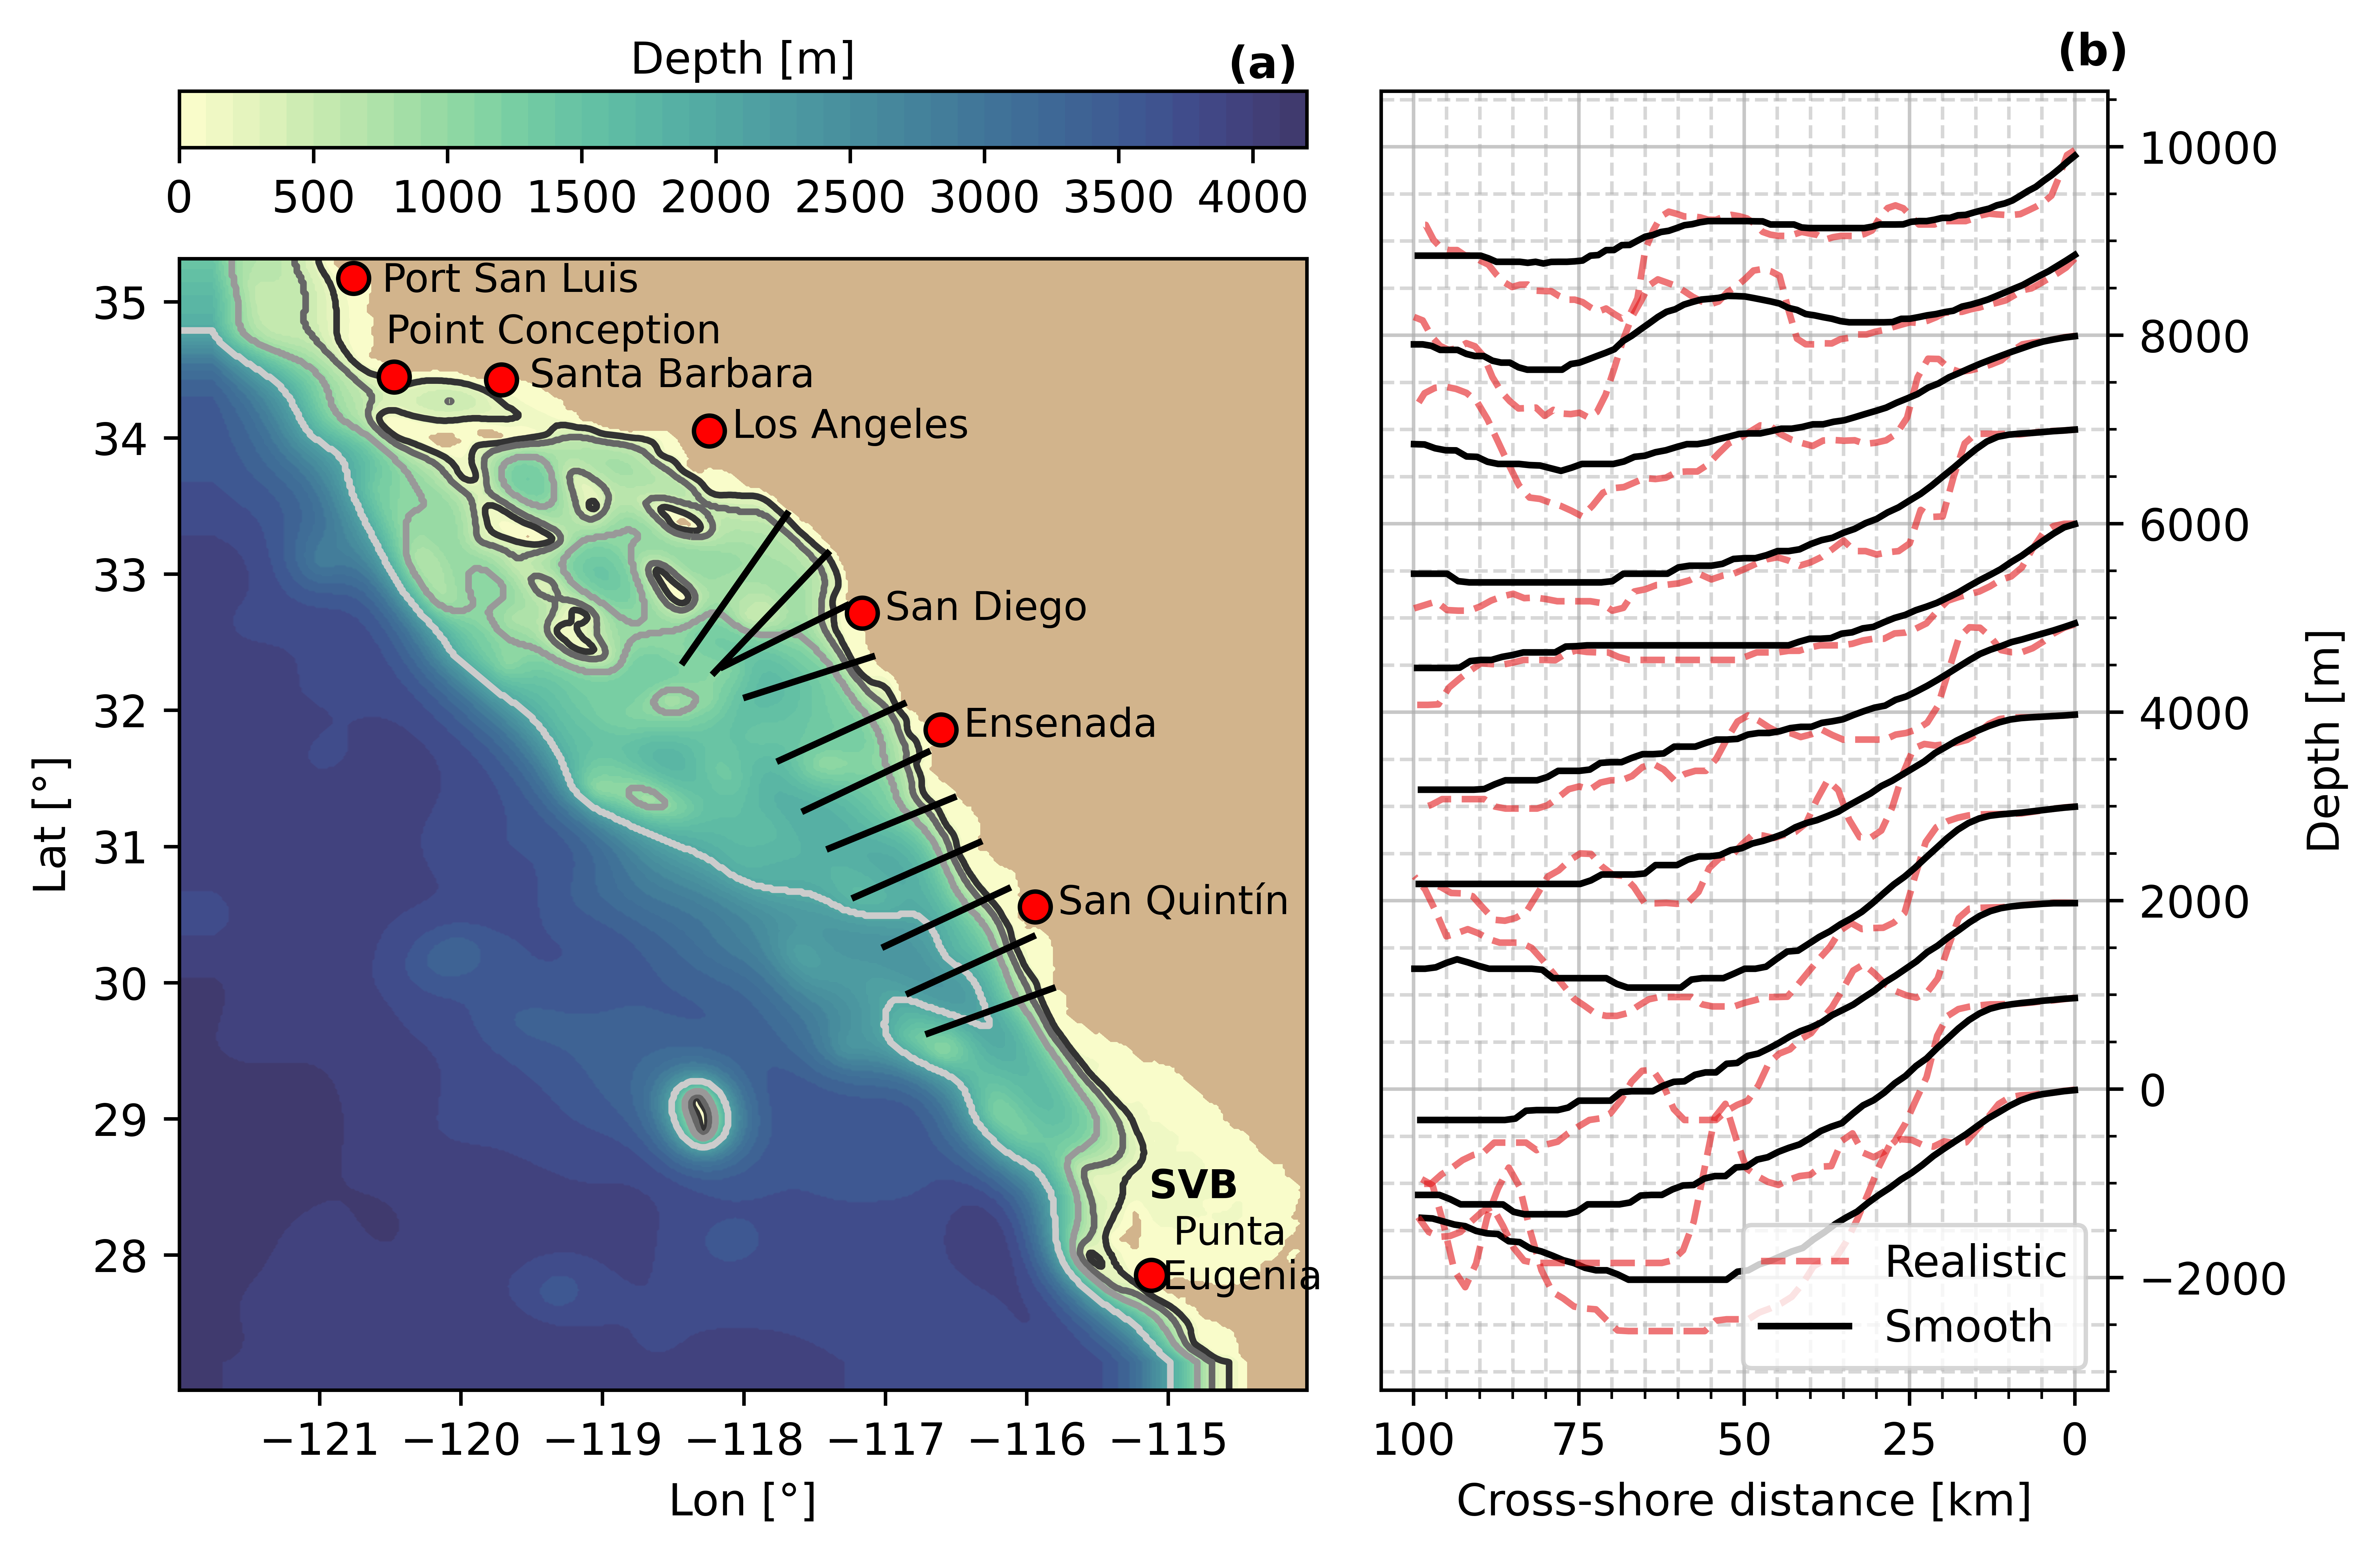

In [13]:
xlab='Wavenumber [10$^3$ * 1/km]'
ylab='Frequency [cpd]'
omega=(2*np.pi)/(23*60*60 + 56*60 + 4.1)
ms=7
fs=9
k=0
fig = plt.figure()
gs = GridSpec(nrows=1, ncols=10)
ax=fig.add_subplot(gs[0, :6])
ax.set_facecolor('tan')
cax = ax.contourf(LON,LAT,np.ma.masked_array(depth, mask=mask[0]), 50,
	         vmin=0, vmax=5000, cmap=cmocean.cm.deep) 
cn = ax.contour(LON, LAT, depth, colors=['0.2', '0.4', '0.6', '0.8'],
                levels=[200, 500, 1000, 2000], zorder=2)


for i in np.arange(0,len(lonPl),1):
    ax.plot(lonPl[i][0],latPl[i][0],color='k')


for kk, ll, lab in zip(ind_lon, ind_lat,
                       ['Punta \n Eugenia', 'San Quintín', 'Ensenada', 'San Diego', 'Los Angeles', 'Santa Barbara',
                        'Point Conception', 'Port San Luis']):
	ax.plot(kk, ll, 'o',markersize=ms, color='r', markeredgecolor='k',zorder=5)
	if lab == 'Point Conception':
		ax.text(kk - 0.06, ll + 0.25, lab, fontsize=fs)
	elif lab == 'Santa Barbara':
		ax.text(kk + 0.2, ll - 0.05, lab, fontsize=fs)
	elif lab == 'Port San Luis':
		ax.text(kk + 0.2, ll - 0.1, lab, fontsize=fs)
	elif lab == 'Punta \n Eugenia':
		ax.text(kk + 0.6, ll - 0.1, lab, fontsize=fs, horizontalalignment='center')
	else:
		ax.text(kk + 0.16, ll - 0.05, lab, fontsize=fs)


ax.text(0.9, 0.17, 'SVB', fontsize=fs, horizontalalignment='center', fontweight='bold',
        transform=ax.transAxes)

ax.text(0.93, 1.16, '(a)', fontweight='bold', color='k', 
transform=ax.transAxes)
ax.set_xlabel('Lon [°]')
ax.set_ylabel('Lat [°]')

divider = make_axes_locatable(ax)
axdiv = divider.new_vertical(size = '5%', pad = 0.35)
fig.add_axes(axdiv)
cbar_ax = plt.colorbar(cax, cax=axdiv,orientation='horizontal')
cbar_ax.ax.xaxis.set_label_position("top")
cbar_ax.set_label('Depth [m]')

ax=fig.add_subplot(gs[0, 6:])

xlab='Cross-shore distance [km]'
ylab='Depth [m]'
for i in np.arange(len(latPl)):
    if i==0:
        ax.plot(x[i][0],-depOrg[i]+1000*i,color='#e41a1c',linestyle='dashed',label='Realistic',alpha=0.6)
        ax.plot(x[i][0],-dep[i]+1000*i,color='k',label='Smooth')
    else:
        ax.plot(x[i][0],-depOrg[i]+1000*i,color='#e41a1c',linestyle='dashed',alpha=0.6)
        ax.plot(x[i][0],-dep[i]+1000*i,color='k')

ax.legend()
ax.xaxis.set_inverted(True)
ax.set(xlabel=xlab, ylabel=ylab)
ax.minorticks_on()
ax.yaxis.set_label_position("right")
ax.yaxis.tick_right()

ax.text(0.93, 1.02, '(b)', fontweight='bold', color='k', 
transform=ax.transAxes)
ax.grid(which='minor',linestyle='--', alpha=0.5)
ax.grid(which='major',alpha=0.7)
fig.tight_layout()
plt.savefig('../figures/SECTSMAP_fig2.pdf', bbox_inches='tight')